In [2]:
import numpy as np
import plotly.graph_objects as go

# --- Z Framework Parameters ---
phi = (1 + np.sqrt(5)) / 2  # The golden ratio, our geometric invariant

# --- Helper Function to Generate Primes ---
def sieve_of_eratosthenes(n):
    """Generates primes up to n using the Sieve of Eratosthenes."""
    primes = np.ones(n + 1, dtype=bool)
    primes[0:2] = False
    for i in range(2, int(np.sqrt(n)) + 1):
        if primes[i]:
            primes[i*i::i] = False
    return np.where(primes)[0]

# --- Core Helical Mapping Function ---
def map_to_helix(numbers):
    """Maps a list of numbers to their (x, y, z) coordinates on a conical helix."""
    n = np.array(numbers)

    # The z-axis is the linear progression of the numbers
    z = n

    # The radius grows logarithmically with n
    r = np.log(n + 1)

    # The angle is determined by the core Z-Framework rotational component
    theta = 2 * np.pi * (n % phi)

    # Convert from cylindrical to Cartesian coordinates
    x = r * np.cos(theta)
    y = r * np.sin(theta)

    return x, y, z

# --- Main Visualization ---
if __name__ == "__main__":
    N = 10000  # Set the upper limit for our visualization

    # 1. Generate the data
    all_numbers = np.arange(2, N)
    prime_numbers = sieve_of_eratosthenes(N)

    # 2. Map the data to our 3D space
    x_path, y_path, z_path = map_to_helix(all_numbers)
    x_primes, y_primes, z_primes = map_to_helix(prime_numbers)

    # 3. Create the 3D plot
    fig = go.Figure()

    # Plot the helical path of all integers (the "trajectory")
    fig.add_trace(go.Scatter3d(
        x=x_path, y=y_path, z=z_path,
        mode='lines',
        line=dict(color='grey', width=1),
        name='Integer Path',
        opacity=0.3
    ))

    # Plot the primes as distinct points on the path
    fig.add_trace(go.Scatter3d(
        x=x_primes, y=y_primes, z=z_primes,
        mode='markers',
        marker=dict(color='blue', size=5, opacity=0.8),
        name='Primes'
    ))

    # 4. Configure the plot for clarity
    fig.update_layout(
        title=f'Helical Trajectory of Primes up to {N}',
        scene=dict(
            xaxis_title='X (log(n) * cos(θ))',
            yaxis_title='Y (log(n) * sin(θ))',
            zaxis_title='Z (n)'
        ),
        margin=dict(l=0, r=0, b=0, t=40)
    )

    print(f"Generated an interactive 3D plot for primes up to {N}.")
    fig.show()

Generated an interactive 3D plot for primes up to 10000.


<>:79: SyntaxWarning:

invalid escape sequence '\m'

<>:79: SyntaxWarning:

invalid escape sequence '\m'

/tmp/ipython-input-19474111.py:79: SyntaxWarning:

invalid escape sequence '\m'



Generated a 3D diagnostic plot for integers up to 10000.
Points are colored by their geometric distance to the prime center mu_p.


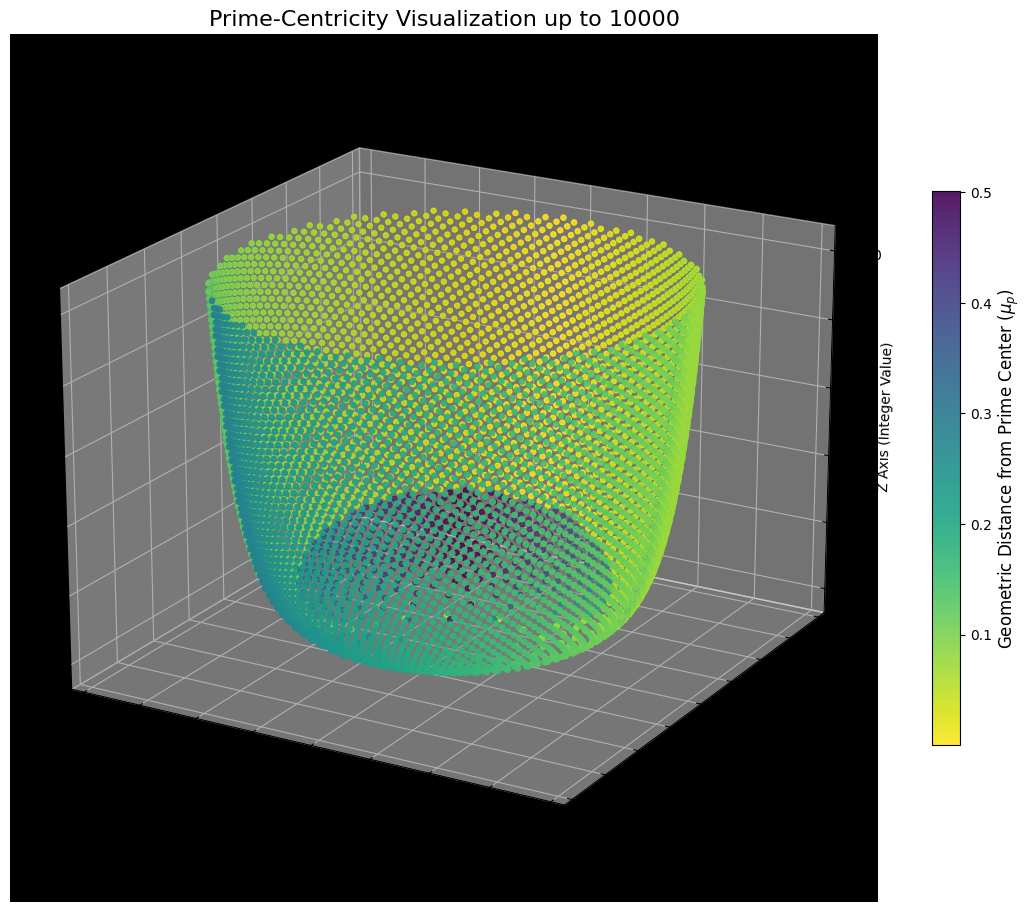

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.colors as mcolors

# --- Z Framework Parameters & Constants ---
phi = (1 + np.sqrt(5)) / 2  # The golden ratio
k_star = 0.3                # Optimal k for geodesic resolution

# This is the empirically derived geometric center from the pull request.
# It's calculated as the mean of frac(theta'(p, k*)) over a large sample of primes.
mu_p = 0.5012

# --- Helper Function to Generate Primes ---
def sieve_of_eratosthenes(n):
    """Generates primes up to n using the Sieve of Eratosthenes."""
    primes = np.ones(n + 1, dtype=bool)
    primes[0:2] = False
    for i in range(2, int(np.sqrt(n)) + 1):
        if primes[i]:
            primes[i*i::i] = False
    return np.where(primes)[0]

# --- Core Geometric and Mapping Functions ---
def frac_theta_prime(n, k=k_star, p=phi):
    """Calculates the fractional part of the geodesic function theta'(n,k)."""
    # Ensure n is an array for vectorization
    n = np.array(n)
    # The geodesic function from the Z Framework
    theta_val = p * ((n % p) / p)**k
    # Return the fractional part
    return theta_val % 1

def compute_center_distance(n, center=mu_p):
    """Computes the geometric distance from the empirical prime center."""
    return np.abs(frac_theta_prime(n) - center)

def map_to_helix(numbers):
    """Maps a list of numbers to their (x, y, z) coordinates on a conical helix."""
    n = np.array(numbers)
    z = n
    r = np.log(n + 1e-9) # Add epsilon to avoid log(0)
    theta = 2 * np.pi * (n % phi)
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return x, y, z

# --- Main Visualization ---
if __name__ == "__main__":
    N = 10000  # Set the upper limit for our visualization

    # 1. Generate the data
    all_numbers = np.arange(2, N)

    # 2. Map all numbers to our 3D space
    x_path, y_path, z_path = map_to_helix(all_numbers)

    # 3. Calculate the geometric distance for each number
    distances = compute_center_distance(all_numbers)

    # 4. Create the 3D plot
    fig = plt.figure(figsize=(14, 12))
    ax = fig.add_subplot(111, projection='3d')

    # 5. Create a color map based on distance.
    # Low distance = prime-like = bright color (yellow)
    # High distance = composite-like = dark color (purple)
    norm = mcolors.Normalize(vmin=np.min(distances), vmax=np.max(distances))
    cmap = plt.get_cmap('viridis_r') # Reversed viridis

    # Plot the full path of all integers as a faint line for context
    ax.plot(x_path, y_path, z_path, color='grey', alpha=0.2, linewidth=0.5)

    # Plot all integers as points, colored by their geometric distance to mu_p
    sc = ax.scatter(x_path, y_path, z_path, c=distances, cmap=cmap, norm=norm, s=15, alpha=0.9)

    # 6. Add a color bar to serve as a legend for the distance metric
    cbar = fig.colorbar(sc, shrink=0.6, aspect=20)
    cbar.set_label('Geometric Distance from Prime Center ($\mu_p$)', fontsize=12)

    # 7. Configure the plot for clarity
    ax.set_title(f'Prime-Centricity Visualization up to {N}', fontsize=16)
    ax.set_xlabel('X Axis')
    ax.set_ylabel('Y Axis')
    ax.set_zlabel('Z Axis (Integer Value)')
    ax.set_facecolor('black') # Use a dark background for better contrast

    # Set a good initial viewing angle
    ax.view_init(elev=20., azim=-60)

    print(f"Generated a 3D diagnostic plot for integers up to {N}.")
    print("Points are colored by their geometric distance to the prime center mu_p.")
    plt.show()

Generated a 3D plot for prime numbers up to 10000.


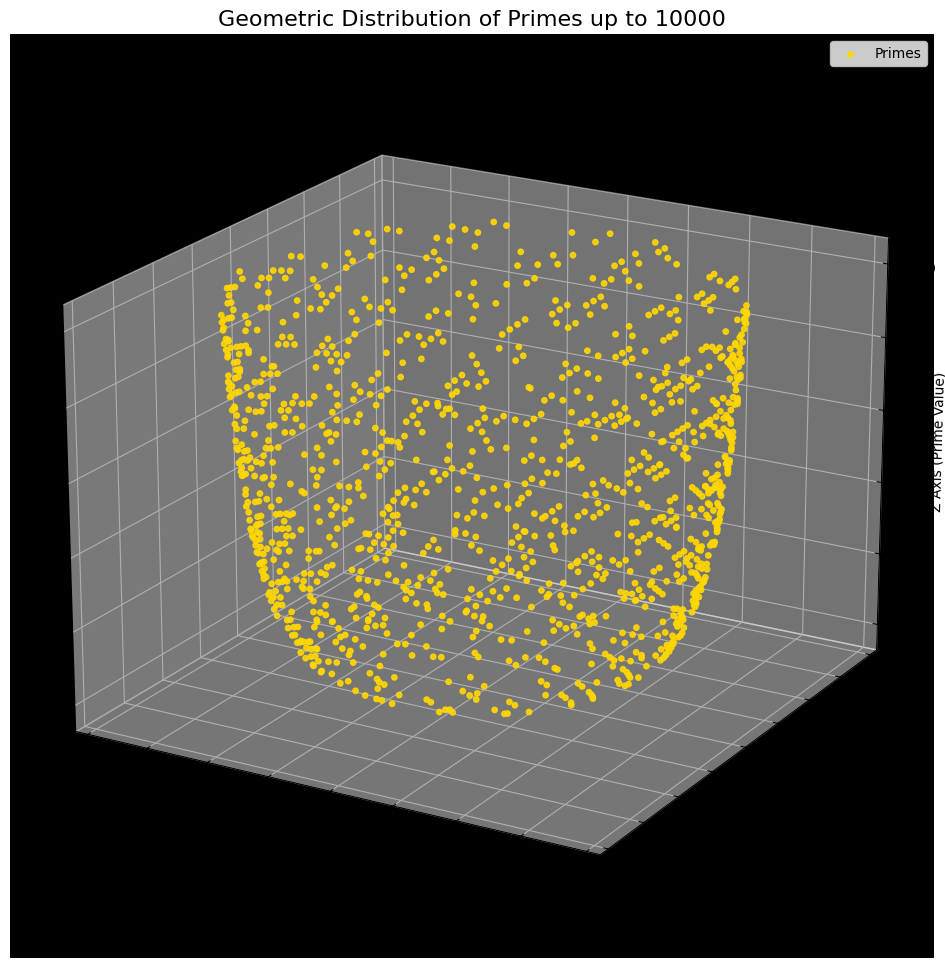

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- Z Framework Parameters ---
phi = (1 + np.sqrt(5)) / 2  # The golden ratio

# --- Helper Function to Generate Primes ---
def sieve_of_eratosthenes(n):
    """Generates primes up to n using the Sieve of Eratosthenes."""
    primes = np.ones(n + 1, dtype=bool)
    primes[0:2] = False
    for i in range(2, int(np.sqrt(n)) + 1):
        if primes[i]:
            primes[i*i::i] = False
    return np.where(primes)[0]

# --- Core Helical Mapping Function ---
def map_to_helix(numbers):
    """Maps a list of numbers to their (x, y, z) coordinates on a conical helix."""
    n = np.array(numbers)
    z = n
    r = np.log(n + 1e-9) # Add epsilon to avoid log(0)
    theta = 2 * np.pi * (n % phi)
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return x, y, z

# --- Main Visualization ---
if __name__ == "__main__":
    N = 10000  # Set the upper limit for our visualization

    # 1. Generate ONLY the prime numbers
    prime_numbers = sieve_of_eratosthenes(N)

    # 2. Map the prime numbers to our 3D space
    x_primes, y_primes, z_primes = map_to_helix(prime_numbers)

    # 3. Create the 3D plot
    fig = plt.figure(figsize=(12, 12))
    ax = fig.add_subplot(111, projection='3d')

    # 4. Plot ONLY the primes as distinct, bright points
    ax.scatter(x_primes, y_primes, z_primes, c='gold', s=15, label='Primes', depthshade=True, alpha=0.9)

    # 5. Configure the plot for clarity
    ax.set_title(f'Geometric Distribution of Primes up to {N}', fontsize=16)
    ax.set_xlabel('X Axis')
    ax.set_ylabel('Y Axis')
    ax.set_zlabel('Z Axis (Prime Value)')
    ax.set_facecolor('black') # Use a dark background for contrast
    ax.grid(True, color='grey', linestyle='--', linewidth=0.5)
    ax.legend()

    # Set a good initial viewing angle
    ax.view_init(elev=20., azim=-60)

    print(f"Generated a 3D plot for prime numbers up to {N}.")
    plt.show()